# ***Import Libraries***

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans , DBSCAN
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import silhouette_score

# ***Load Dataset***

In [12]:
df = pd.read_csv(r"Sample - Superstore.csv" , encoding="latin1")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [13]:
df.info()

#Check Null Values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [14]:
#Remove Duplicates

df.drop_duplicates(inplace=True)

#Convert Dates

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
# Feature Engineering

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Quater"] = df["Order Date"].dt.quarter

df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# ***Exploratory Data Analysis (EDA)***

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64 



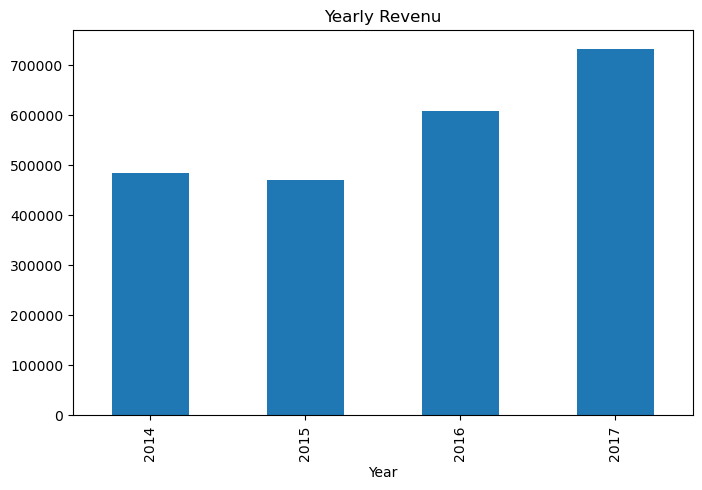

In [16]:
# Revenu Analysis 

revenu = df.groupby("Year")["Sales"].sum()
print(revenu , "\n")

# Visuliztion

revenu.plot(kind= "bar" , figsize=(8,5))
plt.title("Yearly Revenu")
plt.show()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64 



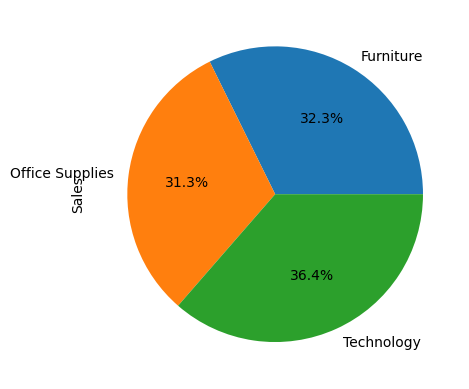

In [17]:
# Customer Category Analysis 

category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales , "\n")

#Visulization

category_sales.plot(kind="pie" ,autopct="%1.1f%%")
plt.show()

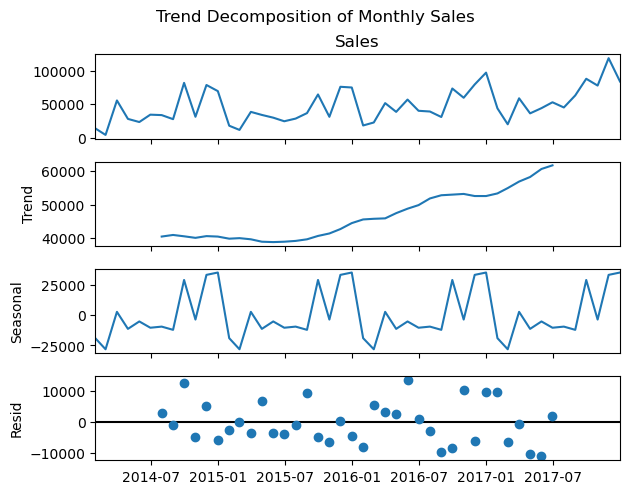

In [19]:
# Trend Decomposition 

# Convert Data Column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Monthly Sales
monthly_sales = df.groupby(pd.Grouper(key="Order Date" , freq="ME"))["Sales"].sum()

#Decomposition
result = seasonal_decompose(monthly_sales , model="additive" , period=12)

#Plot
result.plot()
plt.suptitle("Trend Decomposition of Monthly Sales", y=1.02)
plt.show()

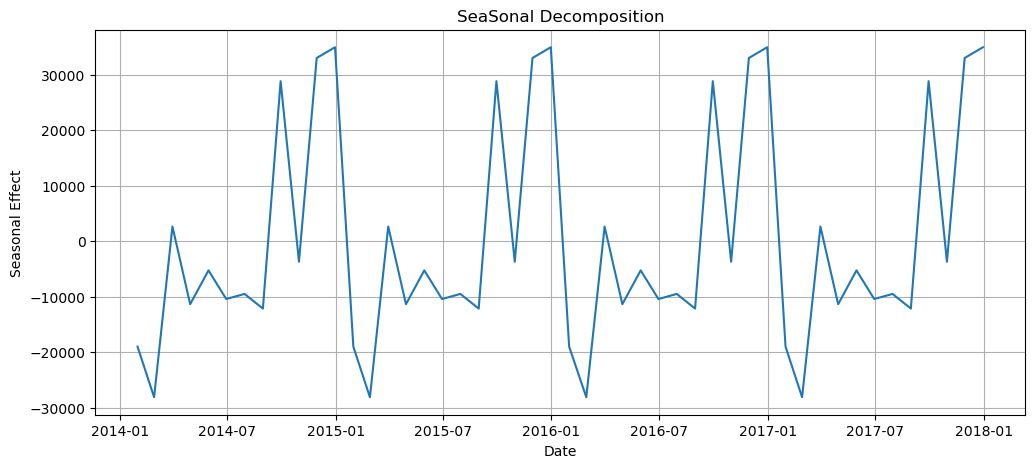

In [20]:
# Seasonal Detection 

seasonal = result.seasonal

plt.figure(figsize=(12,5))
plt.plot(seasonal)
plt.title("SeaSonal Decomposition")
plt.xlabel("Date")
plt.ylabel("Seasonal Effect")
plt.grid(True)
plt.show()

In [22]:
# Anomaly Detection 

# Feature
X = df[["Sales" , "Profit","Quantity"]]

# Model
iso = IsolationForest(contamination=0.02 , random_state=24)

#Prediction
df["Anomaly"] = iso.fit_predict(X)

# Outliers
anomalies = df[df["Anomaly"] == -1]
print("Number of anomalies:", len(anomalies))
anomalies.head()

# Visulization

Number of anomalies: 200


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Day,Quater,Shipping_Days,Anomaly
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,3083.430,7,0.5,-1665.0522,2015,9,17,3,4,-1
149,150,CA-2016-114489,2016-12-05,2016-12-09,Standard Class,JE-16165,Justin Ellison,Corporate,United States,Franklin,...,1951.840,8,0.0,585.5520,2016,12,5,4,4,-1
165,166,CA-2014-139892,2014-09-08,2014-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,8159.952,8,0.4,-1359.9920,2014,9,8,3,4,-1
215,216,CA-2015-146262,2015-01-02,2015-01-09,Standard Class,VW-21775,Victoria Wilson,Corporate,United States,Medina,...,1188.000,9,0.7,-950.4000,2015,1,2,1,7,-1
244,245,CA-2014-131926,2014-06-01,2014-06-06,Second Class,DW-13480,Dianna Wilson,Home Office,United States,Lakeville,...,2001.860,7,0.0,580.5394,2014,6,1,2,5,-1


# ***Advanced Feature Engineering***

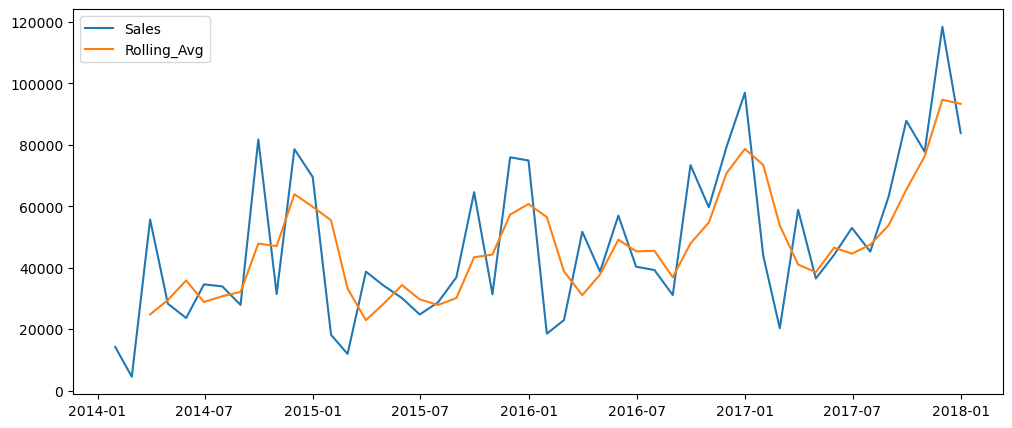

In [23]:
# Rolling Averages 

monthly_sales_rolling=(monthly_sales.rolling(3).mean())

# Visulization

plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.plot(monthly_sales_rolling)

plt.legend(["Sales" , "Rolling_Avg"])
plt.show()

In [24]:
# Lag Feature 

sales_df = monthly_sales.reset_index()
sales_df["lag_1"] = sales_df["Sales"].shift(1)
sales_df["lag_2"] = sales_df["Sales"].shift(2)

sales_df.dropna(inplace=True)

In [25]:
# Growth Rate 

growth_rate = monthly_sales.pct_change()*100
growth_rate.head(5)

Order Date
2014-01-31            NaN
2014-02-28     -68.252263
2014-03-31    1132.131409
2014-04-30     -49.192257
2014-05-31     -16.423401
Freq: ME, Name: Sales, dtype: float64

In [26]:
# Behaviour Clustering Feture 

customer_features = df.groupby("Customer ID").agg({"Sales":"sum","Profit":"sum", "Quantity":"sum"})
customer_features.head()

,Sales,Profit,Quantity
Customer ID,,,
AA-10315,5563.560,-362.8825,30
AA-10375,1056.390,277.3824,41
AA-10480,1790.512,435.8274,36
AA-10645,5086.935,857.8033,64
AB-10015,886.156,129.3465,13


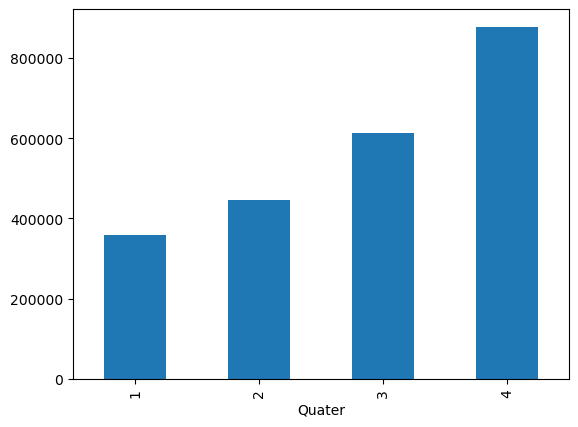

In [27]:
# Time Base Patterns 

df.groupby("Quater")["Sales"].sum().plot(kind="bar")
plt.show()

# ***Machine Learning Models***

In [28]:
# XGBoost 

X = df[["Quantity","Discount","Profit"]]
y = df["Sales"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = XGBRegressor()
model.fit(X_train,y_train)

pred = model.predict(X_test)

In [29]:
# MEA AND MSER 

print("MAE:", mean_absolute_error(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))

MAE: 125.14492391267387
RMSE: 640.5713526355426


In [30]:
# ARIMA 

monthly_sales = df.groupby(
    pd.Grouper(key="Order Date",freq="ME")
)["Sales"].sum()

model = ARIMA(monthly_sales,order=(5,1,0))
forecast = model.fit().forecast(12)

In [32]:
# KMeans Clustering 

customer = df.groupby("Customer ID")[["Sales","Profit","Quantity"]].sum()

kmeans = KMeans(n_clusters=4,random_state=42)
customer["Cluster"] = kmeans.fit_predict(customer)

In [33]:
# DBSCAN Clustering  

dbscan = DBSCAN(eps=0.8,min_samples=5)
labels = dbscan.fit_predict(customer[["Sales","Profit","Quantity"]])

In [34]:
# Silhouette Score 

score = silhouette_score(
    customer[["Sales","Profit","Quantity"]],
    customer["Cluster"]
)

print(score)

0.5047173048372472


# ***Predictive Models***

In [35]:
# Costumer Churn pREDICTION 

customer = df.groupby("Customer ID")["Order Date"].max().reset_index()

last_date = df["Order Date"].max()

customer["Days_Inactive"] = (
    last_date - customer["Order Date"]
).dt.days

customer["Churn"] = (
    customer["Days_Inactive"] > 90
).astype(int)

customer.head()


,Customer ID,Order Date,Days_Inactive,Churn
0,AA-10315,2017-06-29,184,1
1,AA-10375,2017-12-11,19,0
2,AA-10480,2017-04-15,259,1
3,AA-10645,2017-11-05,55,0
4,AB-10015,2016-11-10,415,1


In [37]:
# rEVENU Forcasting 

monthly_sales = df.groupby(
    pd.Grouper(key="Order Date",freq="ME")
)["Sales"].sum()

forecast = ARIMA(
    monthly_sales,
    order=(5,1,0)
).fit().forecast(12)

print(forecast)

2018-01-31    77576.061048
2018-02-28    82260.907001
2018-03-31    79085.524032
2018-04-30    77181.267271
2018-05-31    91222.329404
2018-06-30    85192.547593
2018-07-31    83226.056333
2018-08-31    85814.070169
2018-09-30    82677.685640
2018-10-31    81117.118059
2018-11-30    85149.750965
2018-12-31    83839.154503
Freq: ME, Name: predicted_mean, dtype: float64


In [39]:
# Demand Prediction 

monthly_demand = df.groupby(
    pd.Grouper(key="Order Date",freq="ME")
)["Quantity"].sum()

forecast_demand = ARIMA(
    monthly_demand,
    order=(5,1,0)
).fit().forecast(12)

print(forecast_demand)

2018-01-31    1442.416462
2018-02-28    1423.681525
2018-03-31    1527.613617
2018-04-30    1384.514948
2018-05-31    1509.205919
2018-06-30    1554.018526
2018-07-31    1494.932294
2018-08-31    1492.045702
2018-09-30    1514.662315
2018-10-31    1474.748791
2018-11-30    1488.380807
2018-12-31    1507.015506
Freq: ME, Name: predicted_mean, dtype: float64


In [40]:
# Costumer Lite Time Value 

clv = df.groupby("Customer ID")["Sales"].sum()
clv = clv.reset_index()
clv.columns = [
    "Customer ID",
    "CLV"
]

clv.head()

,Customer ID,CLV
0,AA-10315,5563.560
1,AA-10375,1056.390
2,AA-10480,1790.512
3,AA-10645,5086.935
4,AB-10015,886.156


# ***Business Layers***

In [41]:
# Auto Generate Insignts 

print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

print("Best Region:",
      df.groupby("Region")["Sales"].sum().idxmax())

print("Best Category:",
      df.groupby("Category")["Sales"].sum().idxmax())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Best Region: West
Best Category: Technology


In [42]:
# KPI Monetring System 

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

print("Sales:", total_sales)
print("Profit:", total_profit)
print("Orders:", total_orders)

Sales: 2297200.8603000003
Profit: 286397.0217
Orders: 5009


In [43]:
#Anomaly Detection Alerts

df[df["Sales"] > df["Sales"].quantile(0.99)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Day,Quater,Shipping_Days,Anomaly
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,3083.430,7,0.50,-1665.0522,2015,9,17,3,4,-1
165,166,CA-2014-139892,2014-09-08,2014-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,8159.952,8,0.40,-1359.9920,2014,9,8,3,4,-1
251,252,CA-2016-145625,2016-09-11,2016-09-17,Standard Class,KC-16540,Kelly Collister,Consumer,United States,San Diego,...,3347.370,13,0.00,636.0003,2016,9,11,3,6,-1
262,263,US-2014-106992,2014-09-19,2014-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,3059.982,3,0.40,-509.9970,2014,9,19,3,2,-1
263,264,US-2014-106992,2014-09-19,2014-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,2519.958,7,0.40,-251.9958,2014,9,19,3,2,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9649,9650,CA-2016-107104,2016-11-26,2016-11-30,Standard Class,MS-17365,Maribeth Schnelling,Consumer,United States,Los Angeles,...,3406.664,8,0.15,160.3136,2016,11,26,4,4,-1
9660,9661,CA-2016-160717,2016-06-06,2016-06-11,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Santa Barbara,...,3023.928,9,0.20,226.7946,2016,6,6,2,5,-1
9741,9742,CA-2015-117086,2015-11-08,2015-11-12,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,4404.900,5,0.00,1013.1270,2015,11,8,4,4,-1
9857,9858,CA-2015-164301,2015-03-26,2015-03-30,Standard Class,EB-13840,Ellis Ballard,Corporate,United States,Seattle,...,3393.680,8,0.00,610.8624,2015,3,26,1,4,-1


In [44]:
# Risk Scoring Engine 

df["Risk_Score"] = (df["Discount"] * 100) - df["Profit"]
df[["Sales","Profit","Discount","Risk_Score"]].head()

,Sales,Profit,Discount,Risk_Score
0,261.9600,41.9136,0.00,-41.9136
1,731.9400,219.5820,0.00,-219.5820
2,14.6200,6.8714,0.00,-6.8714
3,957.5775,-383.0310,0.45,428.0310
4,22.3680,2.5164,0.20,17.4836


# ***Install Streamlit***

In [45]:
!pip install streamlit plotly

  You can safely remove it manually.



  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.0
    Uninstalling protobuf-7.35.0:
      Successfully uninstalled protobuf-7.35.0


# ***Decision Recommendation System***

In [47]:
# Decision Recommendation System 

# CUSTOMER LEVEL ANALYSIS
customer = df.groupby("Customer ID")[["Sales", "Profit"]].sum().reset_index()

# CONDITIONS
def segment(row):
    if row["Profit"] > 500 and row["Sales"] > 2000:
        return "High Value Customer"
    elif row["Profit"] < 0:
        return "At Risk Customer"
    else:
        return "Regular Customer"

customer["Segment"] = customer.apply(segment, axis=1)

customer.head()

,Customer ID,Sales,Profit,Segment
0,AA-10315,5563.560,-362.8825,At Risk Customer
1,AA-10375,1056.390,277.3824,Regular Customer
2,AA-10480,1790.512,435.8274,Regular Customer
3,AA-10645,5086.935,857.8033,High Value Customer
4,AB-10015,886.156,129.3465,Regular Customer


In [48]:
# HIGH VALUE CUSTOMERS
high_value = customer[customer["Segment"] == "High Value Customer"]

# AT RISK CUSTOMERS
at_risk = customer[customer["Segment"] == "At Risk Customer"]

print("High Value Customers:", len(high_value))
print("At Risk Customers:", len(at_risk))

High Value Customers: 213
At Risk Customers: 155
